In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv('teleCust1000t.csv')
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


In [7]:
df['custcat'].value_counts()

custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64

<Axes: >

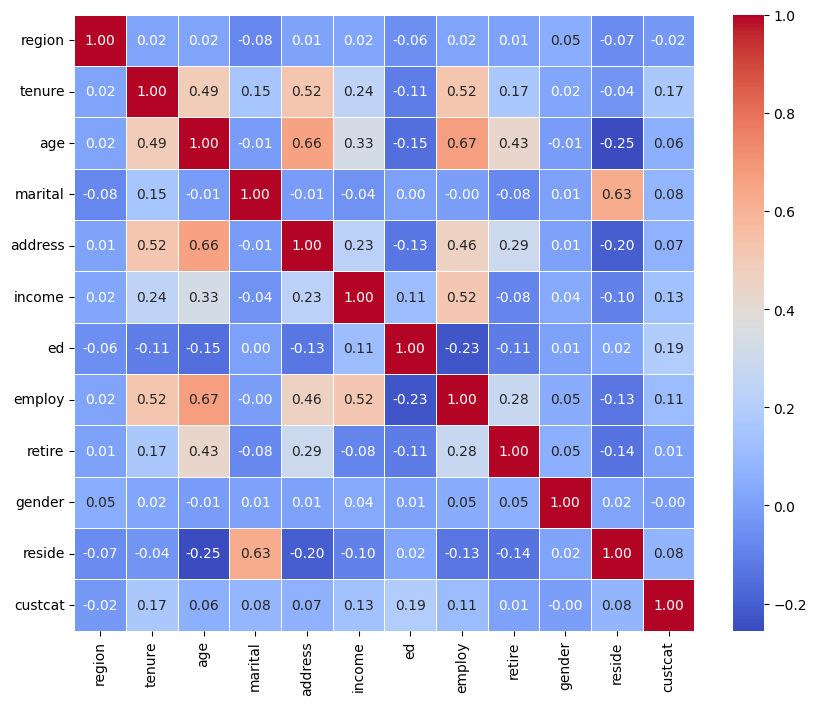

In [8]:
corr = df.corr()

plt.figure(figsize = (10,8))

sns.heatmap(corr,annot = True,cmap = 'coolwarm',fmt = '.2f',linewidth = 0.5)

In [9]:
corr_values = abs(df.corr()['custcat'].drop('custcat')).sort_values(ascending=False)
corr_values

ed         0.193864
tenure     0.166691
income     0.134525
employ     0.110011
marital    0.083836
reside     0.082022
address    0.067913
age        0.056909
region     0.023771
retire     0.008908
gender     0.004966
Name: custcat, dtype: float64

In [10]:
X = df.drop('custcat',axis = 1)
y = df['custcat']

In [11]:
X_norm = StandardScaler().fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=4)

In [17]:
k = 6
knn_classifier = KNeighborsClassifier(n_neighbors=k)
knn_model = knn_classifier.fit(X_train,y_train)

In [18]:
yhat = knn_model.predict(X_test)

In [19]:
accuracy_score(y_test,yhat)

0.31

In [27]:
ks = 100
acc = np.zeros((ks))
std_acc = np.zeros((ks))
for n in range(1,ks+1):
    knn_model_n = KNeighborsClassifier(n_neighbors= n).fit(X_train,y_train)
    yhat = knn_model_n.predict(X_test)
    acc[n-1] = accuracy_score(y_test,yhat)
    std_acc = np.std(yhat ==y_test)/np.sqrt(yhat.shape[0])

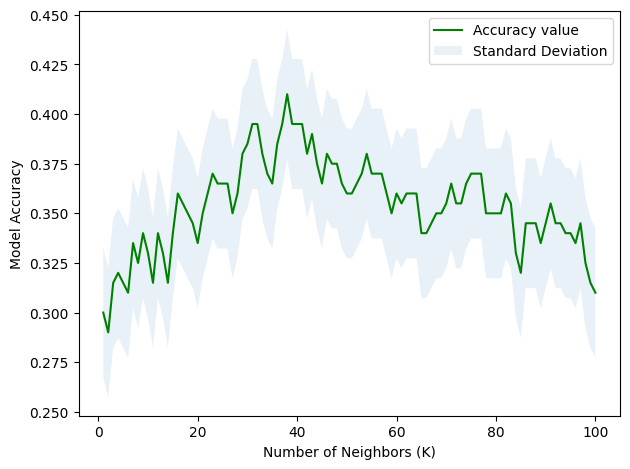

In [28]:
plt.plot(range(1,ks+1),acc,'g')
plt.fill_between(range(1,ks+1),acc - 1 * std_acc,acc + 1 * std_acc, alpha=0.10)
plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

In [29]:
print( "The best accuracy was with", acc.max(), "with k =", acc.argmax()+1) 

The best accuracy was with 0.41 with k = 38
